In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

plt.style.use("ggplot")

df = pd.read_csv("validated_KADIRS_Tax_Compliance.csv")

In [3]:
total_taxpayers = df["taxpayer_id"].nunique()

total_revenue = df["amount_paid"].sum()

total_assessed = df["amount_assessed"].sum()

outstanding = df["outstanding_balance"].sum()

average_score = df["compliance_score"].mean()

payment_rate = (
    (df["payment_status"]=="Paid").mean()*100
)

filing_rate = (
    (df["filing_status"]=="Filed").mean()*100
)

audit_rate = (
    (df["audit_status"]=="Audited").mean()*100
)

In [4]:
kpis = pd.DataFrame({
    "Metric":[
        "Total Taxpayers",
        "Total Revenue",
        "Total Tax Assessed",
        "Outstanding Balance",
        "Average Compliance Score",
        "Payment Compliance (%)",
        "Filing Compliance (%)",
        "Audit Coverage (%)"
    ],
    "Value":[
        total_taxpayers,
        f"₦{total_revenue:,.0f}",
        f"₦{total_assessed:,.0f}",
        f"₦{outstanding:,.0f}",
        round(average_score,2),
        round(payment_rate,2),
        round(filing_rate,2),
        round(audit_rate,2)
    ]
})

kpis

,Metric,Value
0,Total Taxpayers,669
1,Total Revenue,"₦3,922,693,861"
2,Total Tax Assessed,"₦5,180,428,517"
3,Outstanding Balance,"₦1,257,734,656"
4,Average Compliance Score,59.62
5,Payment Compliance (%),67.55
6,Filing Compliance (%),34.95
7,Audit Coverage (%),49.0


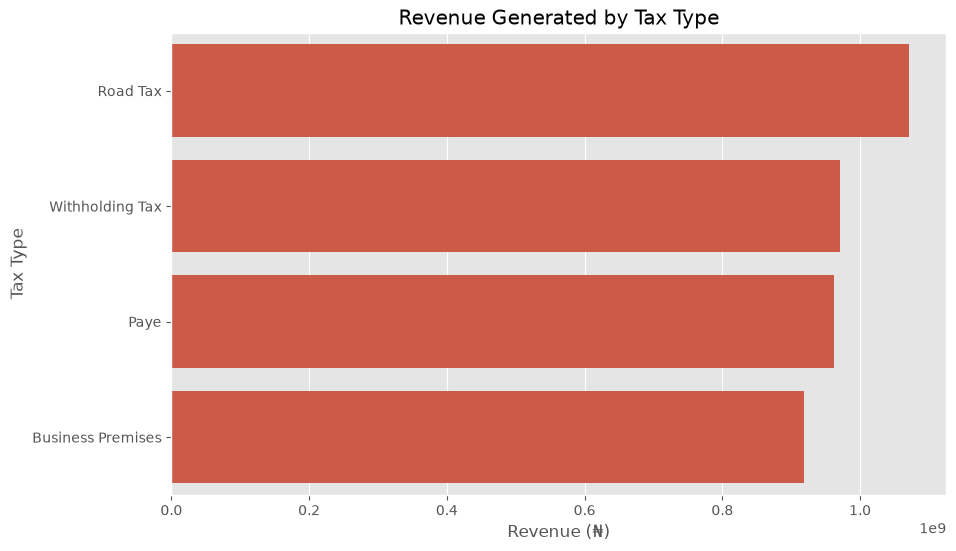

In [5]:
plt.figure(figsize=(10,6))

revenue = df.groupby("tax_type")["amount_paid"]\
            .sum()\
            .sort_values(ascending=False)

sns.barplot(
    x=revenue.values,
    y=revenue.index
)

plt.title("Revenue Generated by Tax Type")

plt.xlabel("Revenue (₦)")

plt.ylabel("Tax Type")

plt.show()
# The chart indicates that an LGA generated the highest tax revenue, suggesting that this tax category contributes significantly to internally generated revenue. This information can guide tax authorities in prioritizing compliance monitoring and revenue optimization efforts.

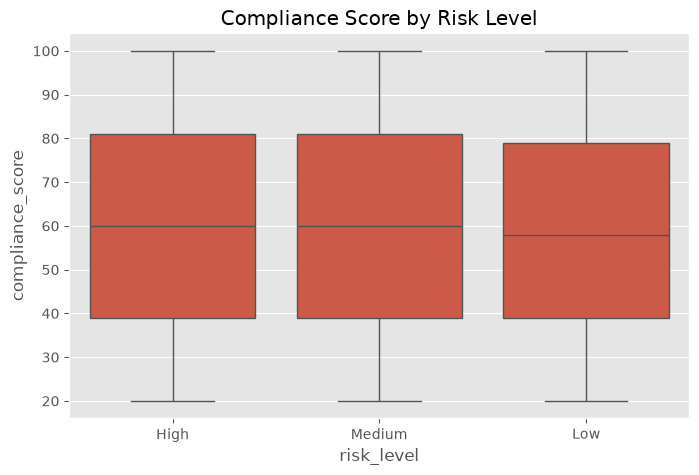

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="compliance_score"
)

plt.title("Compliance Score by Risk Level")

plt.show()
# High-risk taxpayers should generally exhibit lower compliance scores than medium- and low-risk taxpayers, highlighting areas where enforcement and taxpayer engagement may need to be strengthened.

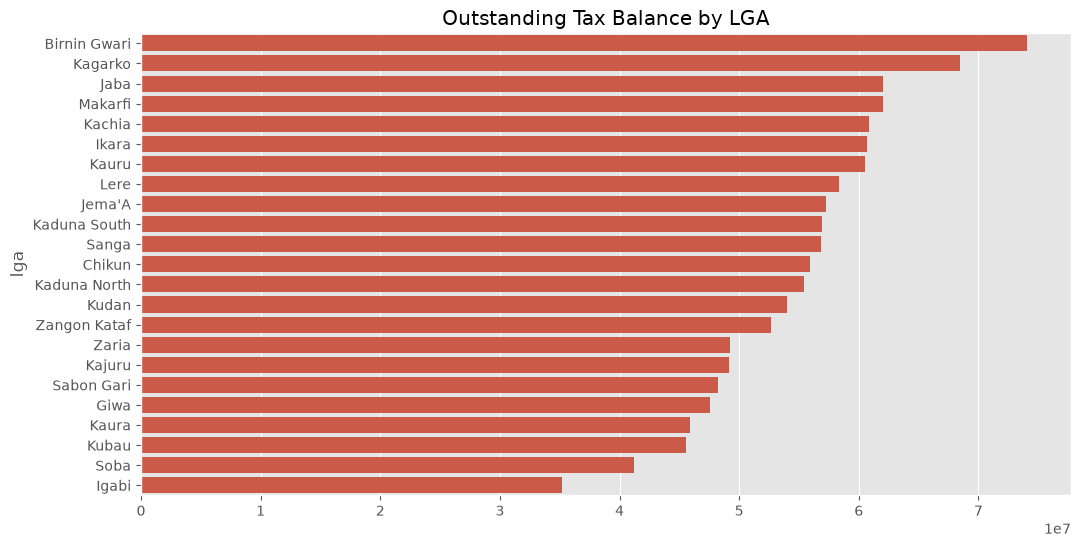

In [7]:
top_balance = df.groupby("lga")["outstanding_balance"]\
                .sum()\
                .sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_balance.values,
    y=top_balance.index
)

plt.title("Outstanding Tax Balance by LGA")

plt.show()

In [8]:
# This visualization identifies LGAs with the largest outstanding tax liabilities, enabling KADIRS to focus debt recovery and compliance campaigns on these areas.

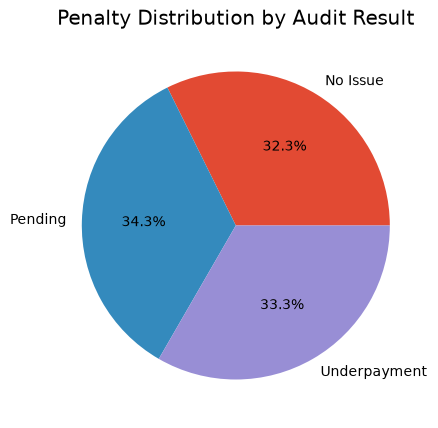

In [9]:
audit = df.groupby("audit_result")["penalty"]\
          .sum()

plt.figure(figsize=(8,5))

audit.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Penalty Distribution by Audit Result")

plt.show()

# This chart illustrates how audit outcomes contribute to penalty collections and can help evaluate the effectiveness of audit activities.

In [10]:
top10 = df.nlargest(
    10,
    "outstanding_balance"
)

top10[
    [
        "business_name",
        "lga",
        "amount_assessed",
        "amount_paid",
        "outstanding_balance"
    ]
]
# This table identifies taxpayers with the highest outstanding balances, providing a basis for targeted compliance and recovery actions.

,business_name,lga,amount_assessed,amount_paid,outstanding_balance
912,Sawyer-Blankenship,Jaba,4845802,89596,4756206
983,"Randall, Henderson and Mcintosh",Makarfi,4958818,316094,4642724
70,Edwards Group,Birnin Gwari,4720271,110116,4610155
1610,Foster-Randolph,Zaria,4859906,264100,4595806
877,Anderson and Sons,Kagarko,4848260,367086,4481174
1960,Hernandez-Hunt,Zangon Kataf,4868742,388762,4479980
1701,"Stanley, Weber and Crawford",Kachia,4975458,510797,4464661
1494,Gonzalez-Stewart,Sanga,4953389,523415,4429974
483,Rodriguez Group,Kachia,4819890,400699,4419191
1164,Turner Inc,Birnin Gwari,4527035,117249,4409786


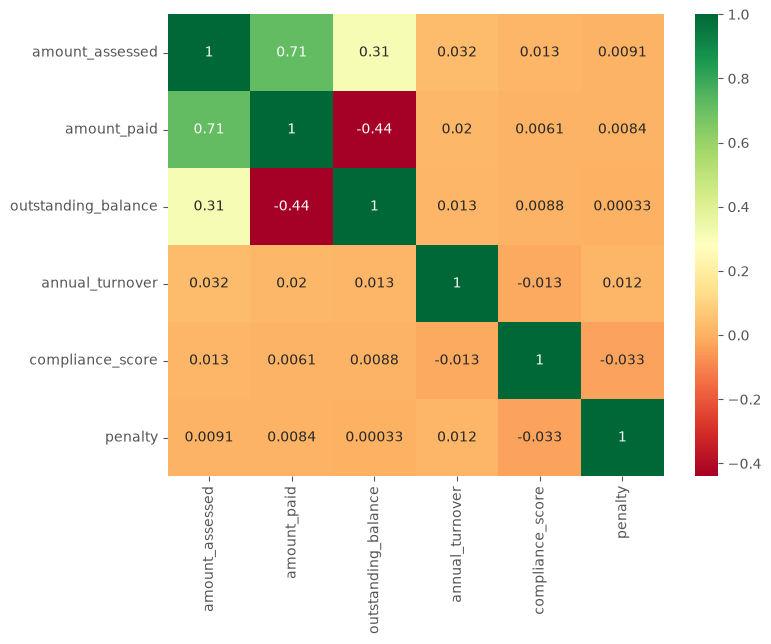

In [11]:
corr = df[
    [
        "amount_assessed",
        "amount_paid",
        "outstanding_balance",
        "annual_turnover",
        "compliance_score",
        "penalty"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr.corr(),
    annot=True,
    cmap="RdYlGn"
)

plt.show()
# The correlation matrix highlights relationships between financial variables and compliance indicators, helping identify which factors are associated with higher tax payments or outstanding balances.

In [12]:
monthly_revenue = df.groupby("tax_month")["amount_paid"].sum()

monthly_revenue.to_csv("monthly_revenue.csv")

In [13]:
monthly_revenue = df.groupby("tax_month")["amount_paid"].sum()

monthly_revenue.to_csv("monthly_revenue.csv")

In [14]:
sector_revenue = df.groupby("business_sector")["amount_paid"].sum()

sector_revenue.to_csv("sector_revenue.csv")

In [ ]:
# The exploratory data analysis provided valuable insights into taxpayer behaviour, revenue generation, filing compliance, payment compliance, audit activities, and outstanding tax liabilities. The analysis identified high-performing tax categories, sectors, and LGAs while highlighting areas requiring increased compliance enforcement. These findings informed the design of the interactive dashboard by identifying the most relevant KPIs and visualizations for monitoring tax compliance.